In [3]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt


In [4]:
#%pip install -e ..

In [5]:
from proj2dhullsampler import HistoryMatching

In [6]:
working_dir = '/glade/work/qingyuany/repo_data/'
case_name = "proj2dsampler_test"

result_name = 'sample1'

In [7]:
test_case = HistoryMatching(working_dir, case_name)
test_case.load_case()
test_case.load_mask(threshold_level=2.0)


In [8]:
test_case.drop_by_name(["local_PRECT_4_7_1_359"])
test_case.drop_by_n_survive(n_survive = 10000)

In [11]:
test_case.remove_var2d_auto(overlapping_threshold = 50000)

There are 0 groups that have no overlapping within own groups
No non-overlapping variables at this stage for the variables sharing the same 2 sensitive parameters
No need to consider non-overlapping
There are 0 groups that have no overlapping within own groups
No non-overlapping variables at this stage for the variables sharing the same 2 sensitive parameters
Finished dropping variables


In [14]:
test_case.drop_by_nvar_per_pair(n_var_thre=1)

In [15]:
test_case.prepare_for_sampling(max_workers = 6)
test_case.draw(n_pts=50000, n_threshold=5000, sample_threshold=10**9, max_workers=10, n_max=1000)

Finish constructing the 2d polygons/convex hulls
Running ('cldfrc_dp1', 'microp_aero_wsubi_scale'), the 0th simulation
There is overlap for ('cldfrc_dp1', 'microp_aero_wsubi_scale'). Proceed to the next parameter pair
Running ('clubb_c1', 'microp_aero_npccn_scale'), the 1th simulation
There is overlap for ('clubb_c1', 'microp_aero_npccn_scale'). Proceed to the next parameter pair
Running ('clubb_c1', 'microp_aero_wsubi_scale'), the 2th simulation
There is overlap for ('clubb_c1', 'microp_aero_wsubi_scale'). Proceed to the next parameter pair
Running ('microp_aero_wsubi_min', 'microp_aero_wsubi_scale'), the 3th simulation
There is overlap for ('microp_aero_wsubi_min', 'microp_aero_wsubi_scale'). Proceed to the next parameter pair
Running ('microp_aero_wsubi_scale', 'microp_aero_npccn_scale'), the 4th simulation
Find nothing from 100000 pts
Find nothing, try to resolve it by breaking the variables into groups
First sample out_prev that needs greater sample size, which will take long
The 

In [16]:
test_case.save_samples_specifications('result5', top_n = 100)

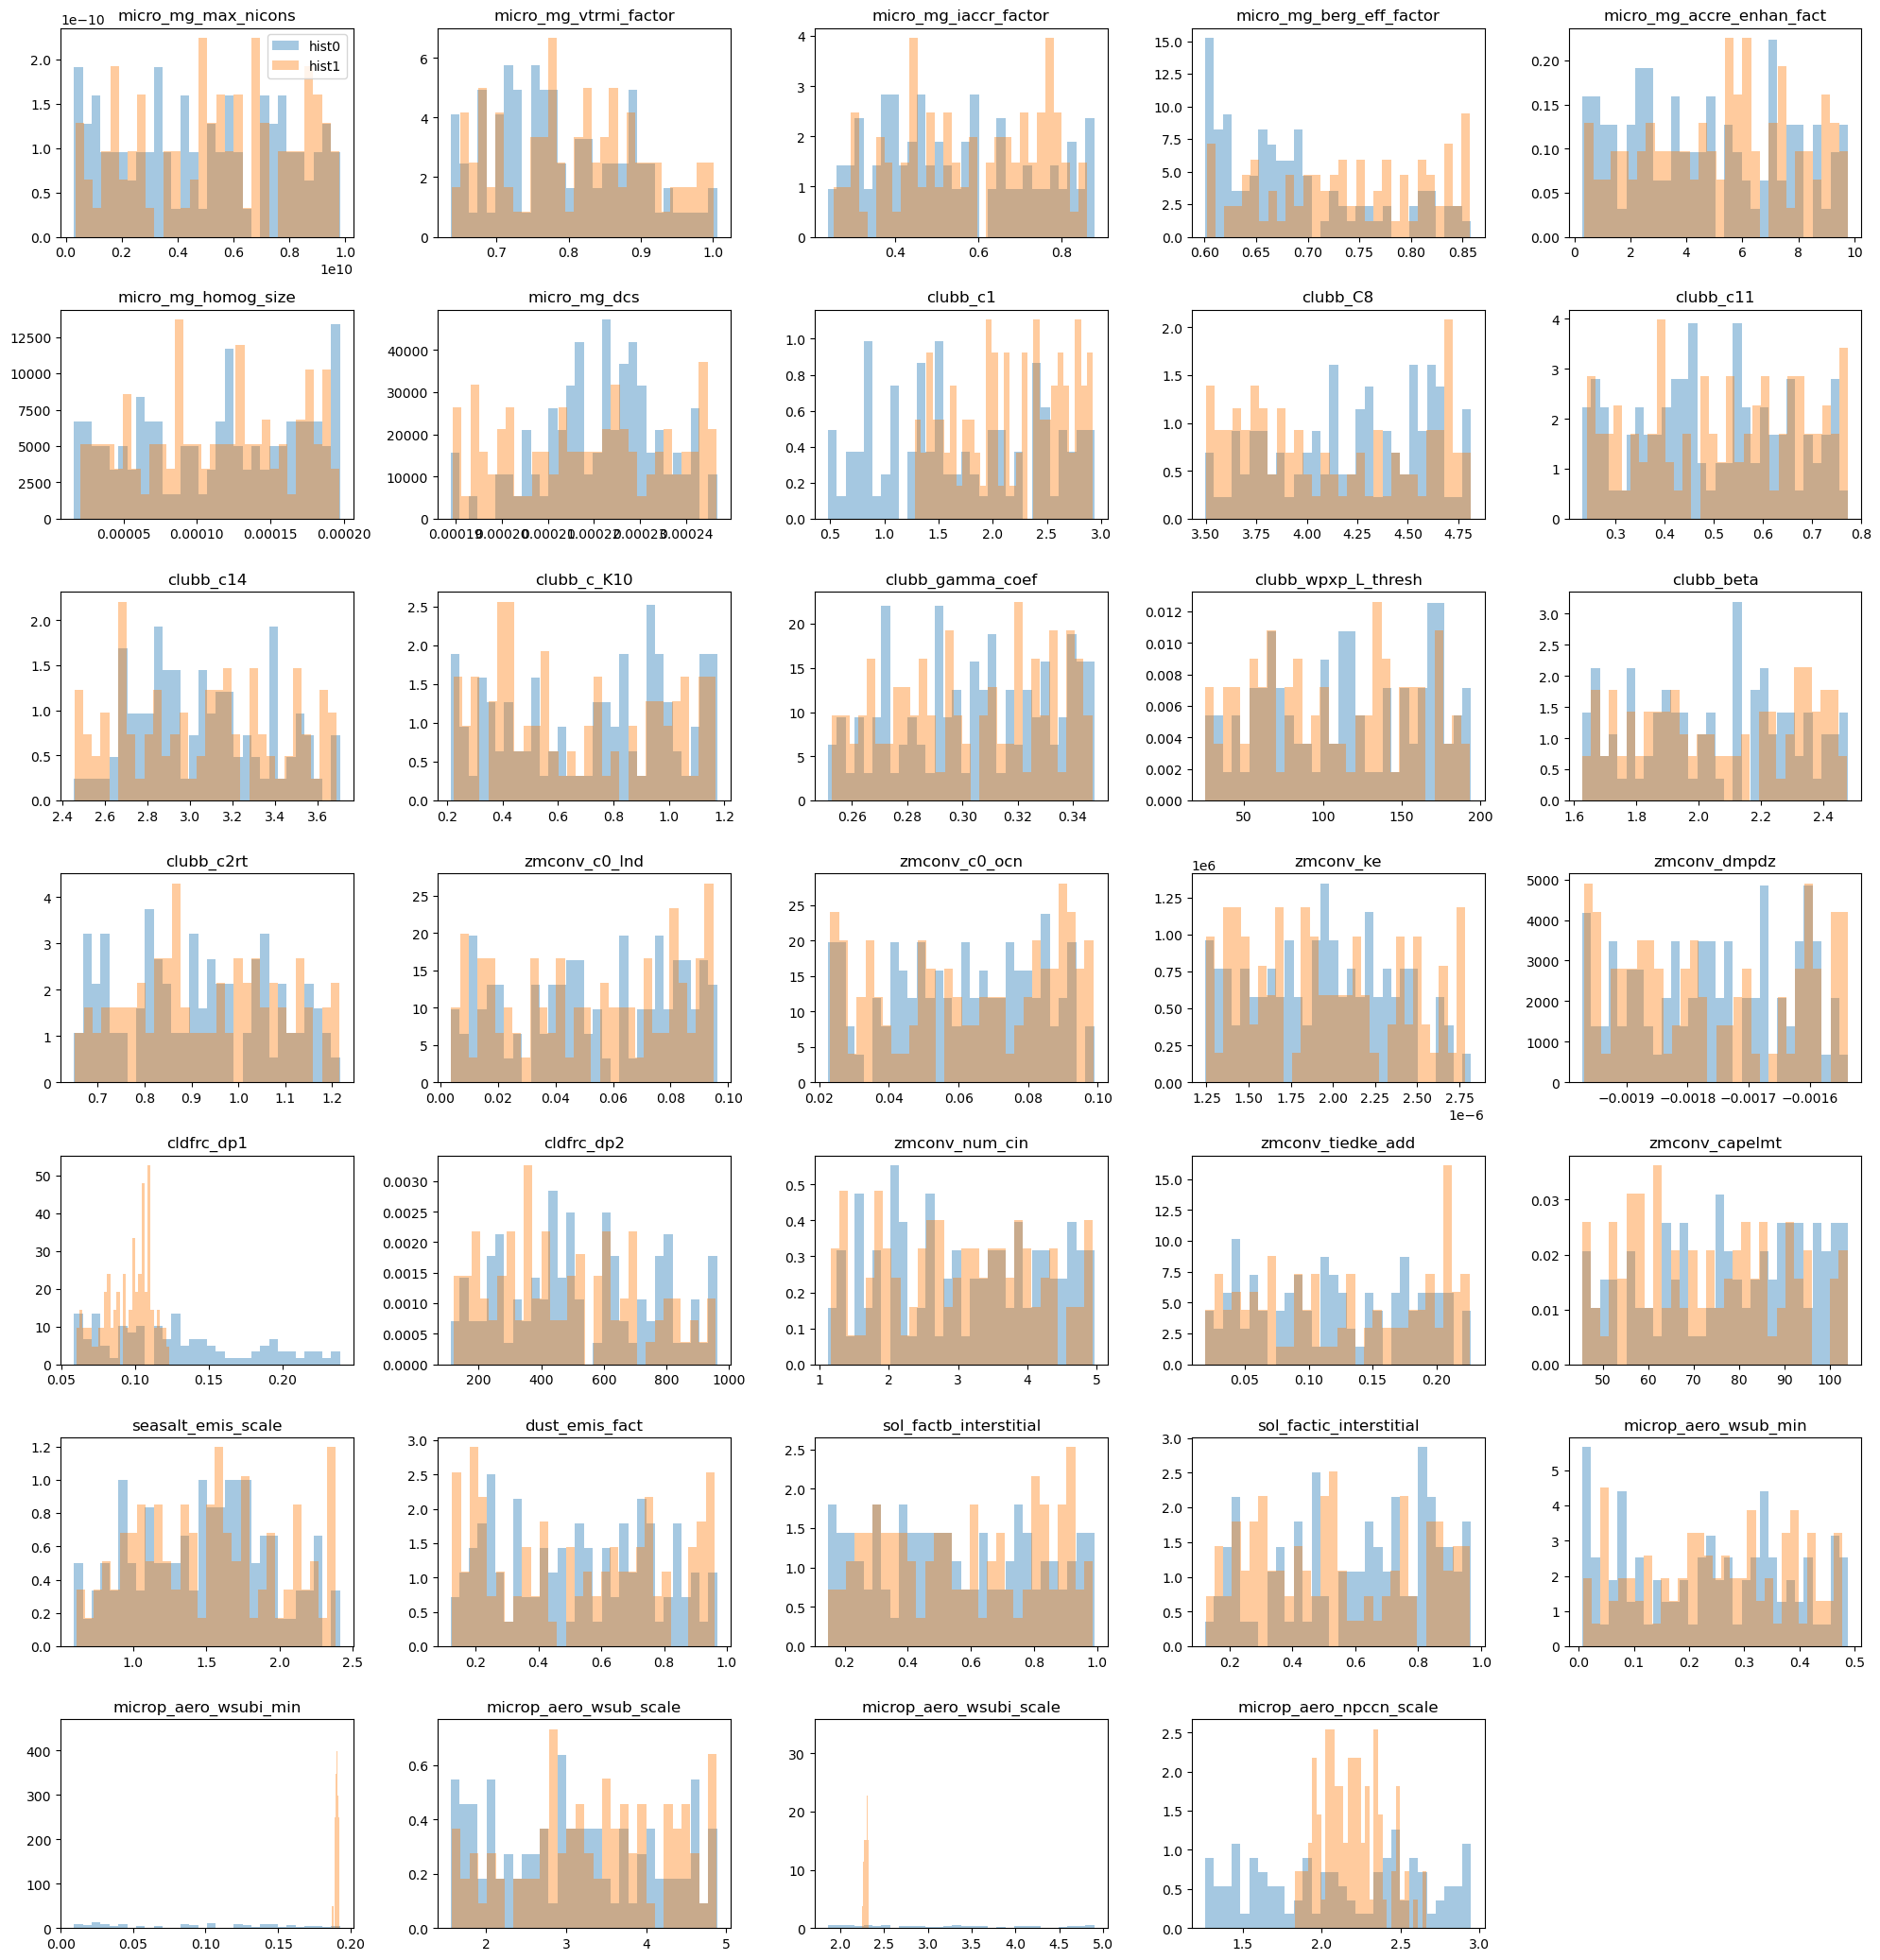

In [18]:
test_case.compare_with_original()